[*********************100%***********************]  1 of 1 completed


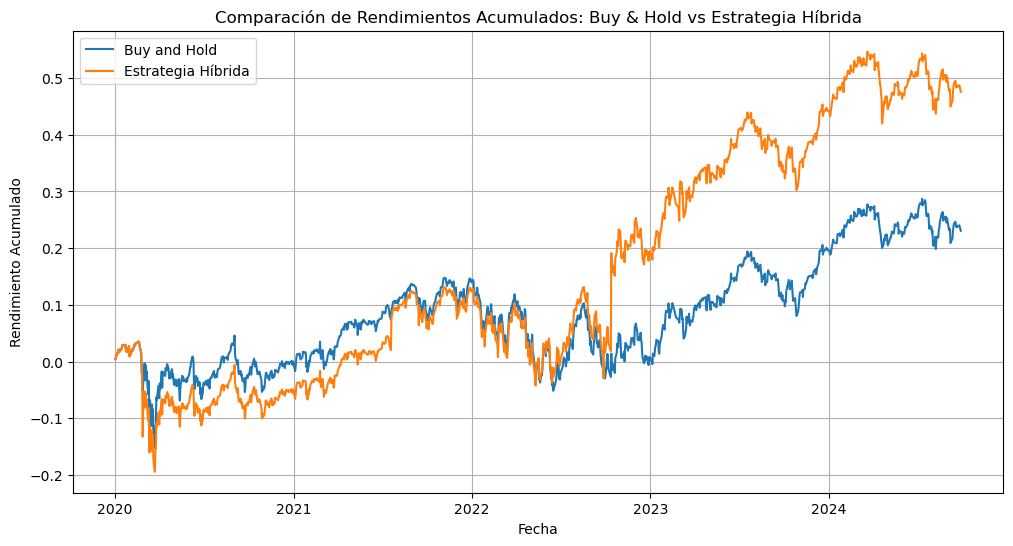

Retorno total del activo (Buy and Hold): 23.07%
Retorno total de la estrategia híbrida: 47.59%
Volatilidad anualizada del activo (Buy and Hold): 16.07%
Volatilidad anualizada de la estrategia híbrida: 19.45%
Retorno anualizado del activo (Buy and Hold): 4.48%
Retorno anualizado de la estrategia híbrida: 8.57%
Ratio de Sharpe del activo (Buy and Hold): 0.22
Ratio de Sharpe de la estrategia híbrida: 0.39
Número total de operaciones (Buy and Hold): 1
Número total de operaciones en la estrategia híbrida: 17.0


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf

# Define el rango de fechas
start_date = '2020-01-01'
end_date = '2024-09-30'

# Especifica el ticker de la acción que deseas obtener
ticker = '^GSPC'

# Descarga los datos históricos
datos_historicos = yf.download(ticker, start=start_date, end=end_date)

# Calcular el rendimiento diario y el signo de cada día
datos_historicos["Return"] = (datos_historicos["Close"] - datos_historicos["Open"]) / datos_historicos["Open"]
datos_historicos['Sign'] = np.where(datos_historicos['Return'] > 0, 1, -1)

# Crear grupos donde el signo cambia
grupo = (datos_historicos['Sign'] != datos_historicos['Sign'].shift()).cumsum()

# Contar días consecutivos dentro de cada grupo
datos_historicos['ConsecCount'] = datos_historicos.groupby(grupo).cumcount() + 1

# Asignar signos positivos o negativos a la cuenta
datos_historicos['Consec'] = datos_historicos['ConsecCount'] * datos_historicos['Sign']

# Inicializar la columna de señales
datos_historicos['Signal'] = 0

# Señal de compra después de 5 días negativos consecutivos
neg_condition = (datos_historicos['Consec'] <= -5)
datos_historicos.loc[neg_condition.shift(1).fillna(False), 'Signal'] = 3

# Estrategia Híbrida: combinación de Buy & Hold con señal
# Posición inicial en la estrategia híbrida: siempre 1 (Buy & Hold)
datos_historicos['Hybrid_Position'] = 1

# Aumentar posición cuando hay una señal
datos_historicos['Hybrid_Position'] += datos_historicos['Signal']

# Calcular el retorno intradiario (de apertura a cierre)
datos_historicos['Intraday_Return'] = (datos_historicos['Close'] - datos_historicos['Open']) / datos_historicos['Open']

# Retorno de la estrategia híbrida: mantener la exposición base (1) y añadir el extra cuando haya señal
datos_historicos['Hybrid_Strategy_Return'] = datos_historicos['Hybrid_Position'] * datos_historicos['Intraday_Return']

# Calcular el rendimiento acumulado de la estrategia híbrida
datos_historicos['Cumulative_Hybrid_Return'] = (1 + datos_historicos['Hybrid_Strategy_Return']).cumprod() - 1

# Calcular el rendimiento acumulado del activo (buy and hold)
datos_historicos['Cumulative_Asset_Return'] = (1 + datos_historicos['Return']).cumprod() - 1

# Visualización de los resultados
plt.figure(figsize=(12, 6))
plt.plot(datos_historicos.index, datos_historicos['Cumulative_Asset_Return'], label='Buy and Hold')
plt.plot(datos_historicos.index, datos_historicos['Cumulative_Hybrid_Return'], label='Estrategia Híbrida')
plt.legend()
plt.title('Comparación de Rendimientos Acumulados: Buy & Hold vs Estrategia Híbrida')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Acumulado')
plt.grid(True)
plt.show()

# Evaluación del rendimiento de Buy & Hold y la Estrategia Híbrida

# Retorno total del activo (Buy and Hold)
total_return_asset = datos_historicos['Cumulative_Asset_Return'].iloc[-1]
print(f"Retorno total del activo (Buy and Hold): {total_return_asset*100:.2f}%")

# Retorno total de la estrategia híbrida
total_return_hybrid = datos_historicos['Cumulative_Hybrid_Return'].iloc[-1]
print(f"Retorno total de la estrategia híbrida: {total_return_hybrid*100:.2f}%")

# Volatilidad anualizada del activo (Buy and Hold)
volatility_asset = datos_historicos['Return'].std() * np.sqrt(252)
print(f"Volatilidad anualizada del activo (Buy and Hold): {volatility_asset*100:.2f}%")

# Volatilidad anualizada de la estrategia híbrida
volatility_hybrid = datos_historicos['Hybrid_Strategy_Return'].std() * np.sqrt(252)
print(f"Volatilidad anualizada de la estrategia híbrida: {volatility_hybrid*100:.2f}%")

# Retorno anualizado del activo (Buy and Hold)
annual_return_asset = (1 + total_return_asset) ** (252 / len(datos_historicos)) - 1
print(f"Retorno anualizado del activo (Buy and Hold): {annual_return_asset*100:.2f}%")

# Retorno anualizado de la estrategia híbrida
annual_return_hybrid = (1 + total_return_hybrid) ** (252 / len(datos_historicos)) - 1
print(f"Retorno anualizado de la estrategia híbrida: {annual_return_hybrid*100:.2f}%")

# Ratio de Sharpe del activo (Buy and Hold) (asumiendo una tasa libre de riesgo de 1%)
risk_free_rate = 0.01
excess_return_asset = annual_return_asset - risk_free_rate
sharpe_ratio_asset = excess_return_asset / volatility_asset
print(f"Ratio de Sharpe del activo (Buy and Hold): {sharpe_ratio_asset:.2f}")

# Ratio de Sharpe de la estrategia híbrida (asumiendo una tasa libre de riesgo de 1%)
excess_return_hybrid = annual_return_hybrid - risk_free_rate
sharpe_ratio_hybrid = excess_return_hybrid / volatility_hybrid
print(f"Ratio de Sharpe de la estrategia híbrida: {sharpe_ratio_hybrid:.2f}")

# Número total de operaciones en Buy & Hold
num_trades_asset = 1
print(f"Número total de operaciones (Buy and Hold): {num_trades_asset}")

# Número total de operaciones en la estrategia híbrida (contando señales de compra)
num_trades_hybrid = datos_historicos['Signal'].sum()
print(f"Número total de operaciones en la estrategia híbrida: {int(num_trades_hybrid)/3}")

Siguientes paso:

1. Ajustar la Exposición de Forma Proporcional (Incremento Gradual)
En lugar de multiplicar la exposición por dos, podrías aumentar la exposición de forma proporcional a la fuerza de la señal o de acuerdo a un sistema escalonado. Por ejemplo, si detectas que el número de días consecutivos de caídas es mayor a 5, podrías aumentar la exposición de forma incremental:

Aumentar un 50% de exposición si hay 5 días consecutivos de caída.
Aumentar un 100% (doblar la posición) si hay 7 días consecutivos de caída.
Este enfoque permite adaptarse mejor a la volatilidad del mercado.

In [ ]:
# Inicializar la posición híbrida: siempre Buy & Hold (posición = 1)
datos_historicos['Hybrid_Position'] = 1

# Ajustar la exposición proporcionalmente según el número de días negativos consecutivos
datos_historicos['Hybrid_Position'] += np.where(datos_historicos['Consec'] <= -7, 1, 
                                                np.where(datos_historicos['Consec'] <= -5, 0.5, 0))


[*********************100%***********************]  1 of 1 completed


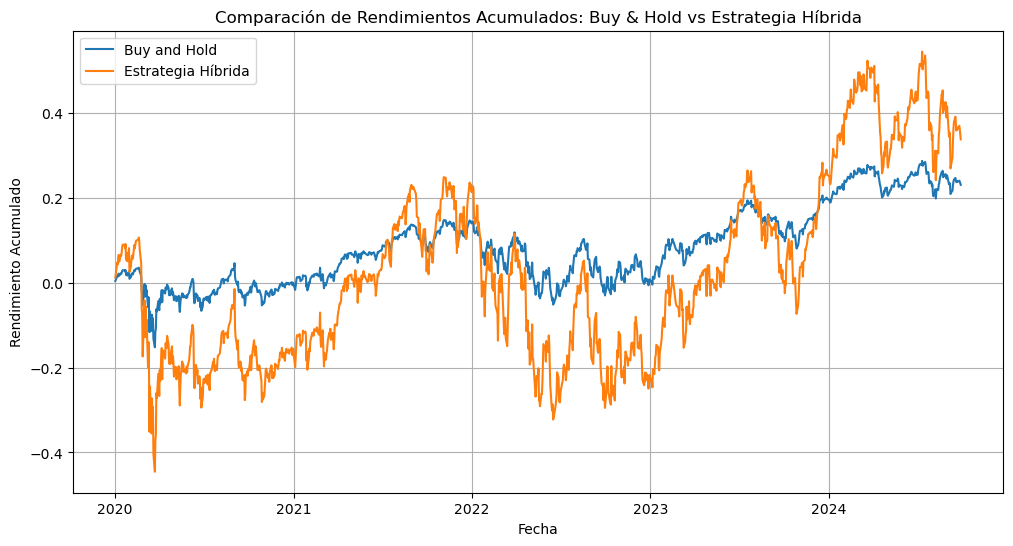

Retorno total del activo (Buy and Hold): 23.07%
Retorno total de la estrategia híbrida: 33.76%
Volatilidad anualizada del activo (Buy and Hold): 16.07%
Volatilidad anualizada de la estrategia híbrida: 48.29%
Retorno anualizado del activo (Buy and Hold): 4.48%
Retorno anualizado de la estrategia híbrida: 6.34%
Ratio de Sharpe del activo (Buy and Hold): 0.22
Ratio de Sharpe de la estrategia híbrida: 0.11
Número total de operaciones (Buy and Hold): 1
Número total de operaciones en la estrategia híbrida: 17


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import yfinance as yf

# Define el rango de fechas
start_date = '2020-01-01'
end_date = '2024-09-30'

# Especifica el ticker de la acción que deseas obtener
ticker = '^GSPC'

# Descarga los datos históricos
datos_historicos = yf.download(ticker, start=start_date, end=end_date)

# Calcular el rendimiento diario y el signo de cada día
datos_historicos["Return"] = (datos_historicos["Close"] - datos_historicos["Open"]) / datos_historicos["Open"]
datos_historicos['Sign'] = np.where(datos_historicos['Return'] > 0, 1, -1)

# Crear grupos donde el signo cambia
grupo = (datos_historicos['Sign'] != datos_historicos['Sign'].shift()).cumsum()

# Contar días consecutivos dentro de cada grupo
datos_historicos['ConsecCount'] = datos_historicos.groupby(grupo).cumcount() + 1

# Asignar signos positivos o negativos a la cuenta
datos_historicos['Consec'] = datos_historicos['ConsecCount'] * datos_historicos['Sign']

# Inicializar la columna de señales
datos_historicos['Signal'] = 0

# Señal de compra después de 5 días negativos consecutivos
neg_condition = (datos_historicos['Consec'] <= -5)
datos_historicos.loc[neg_condition.shift(1).fillna(False), 'Signal'] = 1

# Inicializar la posición híbrida: siempre Buy & Hold (posición = 1)
datos_historicos['Hybrid_Position'] = 1

# Ajustar la exposición proporcionalmente según el número de días negativos consecutivos
datos_historicos['Hybrid_Position'] += np.where(datos_historicos['Consec'] <= -7, 4,
                                                np.where(datos_historicos['Consec'] == -6, 3,
                                                         np.where(datos_historicos['Consec'] == -5, 0.5, 2)))

# Calcular el retorno intradiario (de apertura a cierre)
datos_historicos['Intraday_Return'] = (datos_historicos['Close'] - datos_historicos['Open']) / datos_historicos['Open']

# Retorno de la estrategia híbrida: mantener la exposición base (1) y añadir el extra cuando haya señal
datos_historicos['Hybrid_Strategy_Return'] = datos_historicos['Hybrid_Position'] * datos_historicos['Intraday_Return']

# Calcular el rendimiento acumulado de la estrategia híbrida
datos_historicos['Cumulative_Hybrid_Return'] = (1 + datos_historicos['Hybrid_Strategy_Return']).cumprod() - 1

# Calcular el rendimiento acumulado del activo (buy and hold)
datos_historicos['Cumulative_Asset_Return'] = (1 + datos_historicos['Return']).cumprod() - 1

# Visualización de los resultados
plt.figure(figsize=(12, 6))
plt.plot(datos_historicos.index, datos_historicos['Cumulative_Asset_Return'], label='Buy and Hold')
plt.plot(datos_historicos.index, datos_historicos['Cumulative_Hybrid_Return'], label='Estrategia Híbrida')
plt.legend()
plt.title('Comparación de Rendimientos Acumulados: Buy & Hold vs Estrategia Híbrida')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Acumulado')
plt.grid(True)
plt.show()

# Evaluación del rendimiento de Buy & Hold y la Estrategia Híbrida

# Retorno total del activo (Buy and Hold)
total_return_asset = datos_historicos['Cumulative_Asset_Return'].iloc[-1]
print(f"Retorno total del activo (Buy and Hold): {total_return_asset*100:.2f}%")

# Retorno total de la estrategia híbrida
total_return_hybrid = datos_historicos['Cumulative_Hybrid_Return'].iloc[-1]
print(f"Retorno total de la estrategia híbrida: {total_return_hybrid*100:.2f}%")

# Volatilidad anualizada del activo (Buy and Hold)
volatility_asset = datos_historicos['Return'].std() * np.sqrt(252)
print(f"Volatilidad anualizada del activo (Buy and Hold): {volatility_asset*100:.2f}%")

# Volatilidad anualizada de la estrategia híbrida
volatility_hybrid = datos_historicos['Hybrid_Strategy_Return'].std() * np.sqrt(252)
print(f"Volatilidad anualizada de la estrategia híbrida: {volatility_hybrid*100:.2f}%")

# Retorno anualizado del activo (Buy and Hold)
annual_return_asset = (1 + total_return_asset) ** (252 / len(datos_historicos)) - 1
print(f"Retorno anualizado del activo (Buy and Hold): {annual_return_asset*100:.2f}%")

# Retorno anualizado de la estrategia híbrida
annual_return_hybrid = (1 + total_return_hybrid) ** (252 / len(datos_historicos)) - 1
print(f"Retorno anualizado de la estrategia híbrida: {annual_return_hybrid*100:.2f}%")

# Ratio de Sharpe del activo (Buy and Hold) (asumiendo una tasa libre de riesgo de 1%)
risk_free_rate = 0.01
excess_return_asset = annual_return_asset - risk_free_rate
sharpe_ratio_asset = excess_return_asset / volatility_asset
print(f"Ratio de Sharpe del activo (Buy and Hold): {sharpe_ratio_asset:.2f}")

# Ratio de Sharpe de la estrategia híbrida (asumiendo una tasa libre de riesgo de 1%)
excess_return_hybrid = annual_return_hybrid - risk_free_rate
sharpe_ratio_hybrid = excess_return_hybrid / volatility_hybrid
print(f"Ratio de Sharpe de la estrategia híbrida: {sharpe_ratio_hybrid:.2f}")

# Número total de operaciones en Buy & Hold
num_trades_asset = 1
print(f"Número total de operaciones (Buy and Hold): {num_trades_asset}")

# Número total de operaciones en la estrategia híbrida (contando señales de compra)
num_trades_hybrid = datos_historicos['Signal'].sum()
print(f"Número total de operaciones en la estrategia híbrida: {int(num_trades_hybrid)}")
